In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from sklearn.preprocessing import MinMaxScaler

In [4]:
np.random.seed(42)
data = {
'id': range(1, 21),
'name': [f'Student_{i}' for i in range(1, 21)],
'gender': np.random.choice(['Male', 'Female'], 20),
'age': np.random.randint(18, 25, 20),
'class': np.random.choice(['sr', 'jr'], 20),
'cgpa': np.random.uniform(2.0, 4.0, 20),
'attendance': np.random.uniform(50, 100, 20),
'test_score': np.random.randint(50, 100, 20),
'dept': np.random.choice(['CS', 'Math', 'Physics', 'Chemistry'], 20)
}
df = pd.DataFrame(data)

In [5]:
df


,id,name,gender,age,class,cgpa,attendance,test_score,dept
0,1,Student_1,Male,23,jr,2.341048,88.756641,93,Chemistry
1,2,Student_2,Female,22,jr,2.130103,96.974947,57,Physics
2,3,Student_3,Male,19,jr,3.897771,94.741368,73,Physics
3,4,Student_4,Male,21,jr,3.931264,79.894999,60,Math
4,5,Student_5,Male,23,jr,3.616795,96.093712,66,Chemistry
5,6,Student_6,Female,23,sr,2.609228,54.424625,57,CS
6,7,Student_7,Male,19,jr,2.195344,59.799143,84,Physics
7,8,Student_8,Male,21,jr,3.368466,52.261364,84,Chemistry
8,9,Student_9,Male,22,sr,2.880305,66.266517,82,Chemistry
9,10,Student_10,Female,18,jr,2.244076,69.433864,54,Math


In [6]:
df.loc[3, 'cgpa'] = np.nan # Missing CGPA value
df.loc[7, 'attendance'] = -5

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          20 non-null     int64  
 1   name        20 non-null     object 
 2   gender      20 non-null     object 
 3   age         20 non-null     int64  
 4   class       20 non-null     object 
 5   cgpa        19 non-null     float64
 6   attendance  20 non-null     float64
 7   test_score  20 non-null     int64  
 8   dept        20 non-null     object 
dtypes: float64(2), int64(3), object(4)
memory usage: 1.5+ KB


In [9]:
df.describe()

,id,age,cgpa,attendance,test_score
count,20.00000,20.000000,19.000000,20.000000,20.000000
mean,10.50000,20.850000,2.898388,72.712476,72.650000
std,5.91608,1.899446,0.624063,24.001746,14.068535
min,1.00000,18.000000,2.068777,-5.000000,54.000000
25%,5.75000,19.000000,2.355379,62.625374,57.750000
50%,10.50000,21.000000,2.880305,73.284334,75.000000
75%,15.25000,22.250000,3.346755,90.441606,84.000000
max,20.00000,24.000000,3.939169,99.344347,93.000000


In [17]:
df.isnull()

,id,name,gender,age,class,cgpa,attendance,test_score,dept
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False


In [18]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


,cgpa
0,2.341048
1,2.130103
2,3.897771
3,2.898388
4,3.616795
5,2.609228
6,2.195344
7,3.368466
8,2.880305
9,2.244076


In [26]:
cgpa_mean = df['cgpa'].mean()
df['cgpa'] = df['cgpa'].fillna(cgpa_mean)

In [27]:
df['cgpa']


,cgpa
0,2.341048
1,2.130103
2,3.897771
3,2.898388
4,3.616795
5,2.609228
6,2.195344
7,3.368466
8,2.880305
9,2.244076


In [28]:
df['attendance']

,attendance
0,88.756641
1,96.974947
2,94.741368
3,79.894999
4,96.093712
5,54.424625
6,59.799143
7,-5.000000
8,66.266517
9,69.433864


In [29]:
for i in df.index:
  if df.loc[i, 'attendance'] < 0:
    df.loc[i, 'attendance'] = df['attendance'].median()

In [30]:
df['attendance']

,attendance
0,88.756641
1,96.974947
2,94.741368
3,79.894999
4,96.093712
5,54.424625
6,59.799143
7,73.284334
8,66.266517
9,69.433864


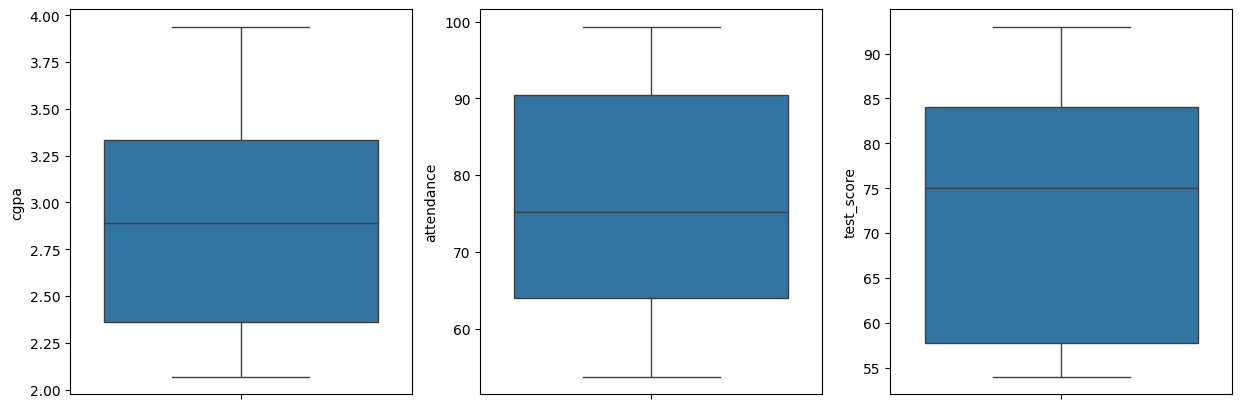

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['cgpa'], ax=ax[0])
sns.boxplot(y=df['attendance'], ax=ax[1])
sns.boxplot(y=df['test_score'], ax=ax[2])
plt.show()

In [33]:
for col in ['cgpa', 'attendance', 'test_score']:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

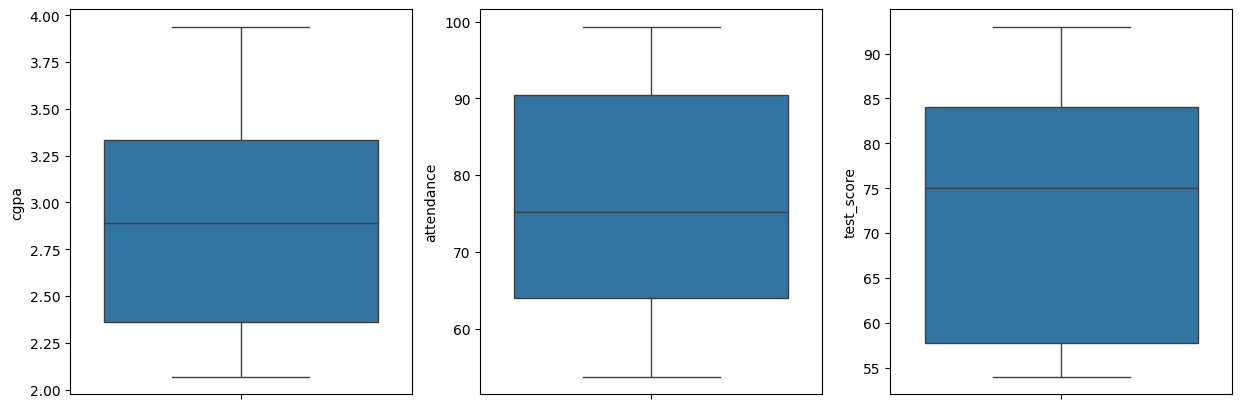

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['cgpa'], ax=ax[0])
sns.boxplot(y=df['attendance'], ax=ax[1])
sns.boxplot(y=df['test_score'], ax=ax[2])
plt.show()

In [36]:
df.describe()

,id,age,cgpa,attendance,test_score
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,20.850000,2.898388,76.626693,72.650000
std,5.91608,1.899446,0.607418,15.560186,14.068535
min,1.00000,18.000000,2.068777,53.727532,54.000000
25%,5.75000,19.000000,2.362544,63.926907,57.750000
50%,10.50000,21.000000,2.889346,75.209569,75.000000
75%,15.25000,22.250000,3.335900,90.441606,84.000000
max,20.00000,24.000000,3.939169,99.344347,93.000000


In [37]:
print(df.head())

   id       name  gender  age class      cgpa  attendance  test_score  \
0   1  Student_1    Male   23    jr  2.341048   88.756641          93   
1   2  Student_2  Female   22    jr  2.130103   96.974947          57   
2   3  Student_3    Male   19    jr  3.897771   94.741368          73   
3   4  Student_4    Male   21    jr  2.898388   79.894999          60   
4   5  Student_5    Male   23    jr  3.616795   96.093712          66   

        dept  
0  Chemistry  
1    Physics  
2    Physics  
3       Math  
4  Chemistry  


In [38]:
scaler = MinMaxScaler()
df['attendance_scaled'] = scaler.fit_transform(df[['attendance']])

In [39]:
print(df.head(20))

    id        name  gender  age class      cgpa  attendance  test_score  \
0    1   Student_1    Male   23    jr  2.341048   88.756641          93   
1    2   Student_2  Female   22    jr  2.130103   96.974947          57   
2    3   Student_3    Male   19    jr  3.897771   94.741368          73   
3    4   Student_4    Male   21    jr  2.898388   79.894999          60   
4    5   Student_5    Male   23    jr  3.616795   96.093712          66   
5    6   Student_6  Female   23    sr  2.609228   54.424625          57   
6    7   Student_7    Male   19    jr  2.195344   59.799143          84   
7    8   Student_8    Male   21    jr  3.368466   73.284334          84   
8    9   Student_9    Male   22    sr  2.880305   66.266517          82   
9   10  Student_10  Female   18    jr  2.244076   69.433864          54   
10  11  Student_11    Male   21    sr  2.990354   63.567452          91   
11  12  Student_12    Male   19    jr  2.068777   91.436875          88   
12  13  Student_13    Mal